# Training neural network: Data augmentation

Tiếp nối bài thực hành trên lớp, bài tập về nhà này vẫn sử dụng MNIST là tập dữ liệu thử nghiệm. Mục tiêu là cải thiện hiệu suất của mô hình bằng các kỹ thuật Augmentation nhằm tăng cường số lượng dữ liệu

In [3]:
import warnings
warnings.filterwarnings('ignore')
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2 
from torchvision.datasets import MNIST
from torchvision import transforms
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

%load_ext tensorboard
shutil.rmtree('./graph/dropout/dropout=0.5,relu/', ignore_errors=True)

In [4]:
import numpy as np
from torchvision.datasets import MNIST
from torchvision import transforms

mnist_train = MNIST(root='../data', train=True,  download=True, transform=transforms.ToTensor())
mnist_test  = MNIST(root='../data', train=False, download=True, transform=transforms.ToTensor())

x_train = mnist_train.data.numpy().astype('float32')
y_train = mnist_train.targets.numpy()
x_test  = mnist_test.data.numpy().astype('float32')
y_test  = mnist_test.targets.numpy()

print('Training image: ', x_train.shape)
print('Testing image: ', x_test.shape)
print('Training label: ', y_train.shape)
print('Testing label: ', y_test.shape)

Training image:  (60000, 28, 28)
Testing image:  (10000, 28, 28)
Training label:  (60000,)
Testing label:  (10000,)


In [5]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255



In [6]:
class SimpleModel(nn.Module):
    def __init__(self, dropout_rate):
        super(SimpleModel, self).__init__()
        self.dense_1 = nn.Linear(28*28, 128)
        self.dropout = nn.Dropout(dropout_rate)
        self.dense_2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.dense_1(x)
        x = self.relu(x)
        x = self.dropout(x)
        output = F.log_softmax(self.dense_2(x))
        
        return output

# Check model parameter

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
simple_model = SimpleModel(dropout_rate=0.5).to(device)
for param in simple_model.parameters():
    if param.requires_grad:
        print('param autograd')
        break

input = torch.rand(1, 28, 28).to(device)
output = simple_model(input)

model_parameters = filter(lambda p: p.requires_grad, simple_model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print('Number of parameter:', params)


param autograd
Number of parameter: 101770


## Tăng thêm dữ liệu (data augmentation) với thư viện imgaug

Trong phần thực hành này, chúng ta sẽ làm quen với các phương pháp tăng dữ liệu cho bài toán xử lý ảnh, các phương pháp này hoàn toàn có thể lập trình sử dụng thư viện numpy (vì bản chất của phương pháp là ta thao tác trên ma trận biểu diễn ảnh). Tuy nhiên, để việc lập trình được nhanh chóng, chúng ta sẽ làm quen với một thư viện rất mạnh mẽ, giúp ta nhanh chóng cài đặt nhiều phương pháp tăng dữ liệu hiệu quả khác nhau: thư viện imgaug

Để cài đặt imgaug, ta sử dụng lệnh:

pip install imgaug

pip install scikit-image --upgrade

In [8]:
!pip install albumentations


In [9]:
import albumentations as A
import numpy as np


Để tìm hiểu lần lượt các phương pháp, thử áp dụng trên ảnh cat.jpg trong thư mục bài thực hành:

In [10]:
# Local environment — no Google Drive mount needed

In [11]:
# Local environment — skipping drive ls

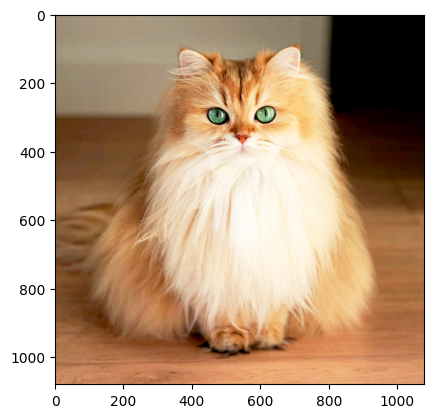

In [12]:
image = cv2.imread('cat.jpg')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

### Các phương pháp thường sử dụng

Các phương pháp hay được sử dụng nhất trong các bài toán xử lý ảnh có thể tham khảo tại: https://imgaug.readthedocs.io/en/latest/source/augmenters.html

1. CropAndPad: Cắt hoặc thêm các pixel vào ảnh.

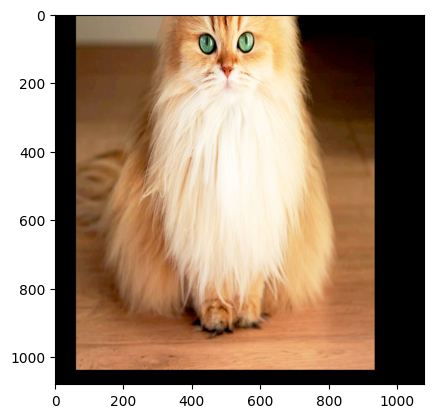

In [13]:
# CropAndPad: crop hoặc pad ảnh (percent âm = crop, dương = pad)
crop_and_pad = A.CropAndPad(percent=(-0.25, 0.25), p=1.0)

img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = crop_and_pad(image=img_rgb)['image']
plt.imshow(result)
plt.show()


2. Flip: Flip left-right hoặc Flip up-down một số ảnh trong tập ảnh truyền vào 

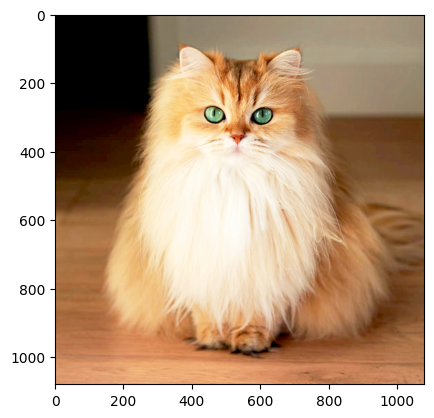

In [14]:
# Flip left-right
flip_lr = A.HorizontalFlip(p=1.0)

img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = flip_lr(image=img_rgb)['image']
plt.imshow(result)
plt.show()


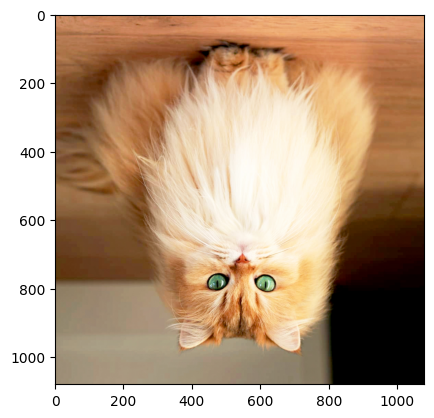

In [15]:
# Flip up-down
flip_ud = A.VerticalFlip(p=1.0)

img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = flip_ud(image=img_rgb)['image']
plt.imshow(result)
plt.show()


- Affine: Các phép biến đổi affine như scale, rotate, translate:

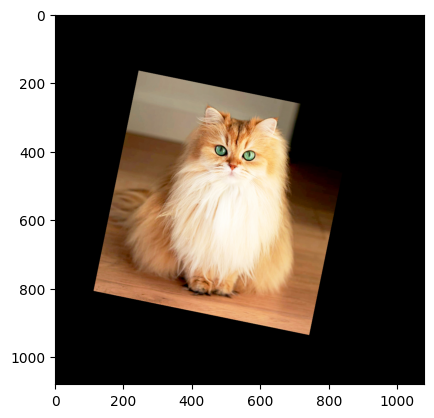

In [16]:
# Affine: scale, rotate, translate
affine = A.Affine(scale=(0.5, 1.5), rotate=(-15, 15), translate_percent=(-0.2, 0.2), p=1.0)

img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = affine(image=img_rgb)['image']
plt.imshow(result)
plt.show()


- Blur: Sử dụng các bộ lọc Gaussian hoặc Mean:

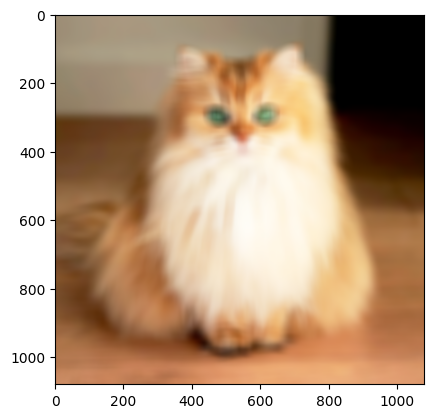

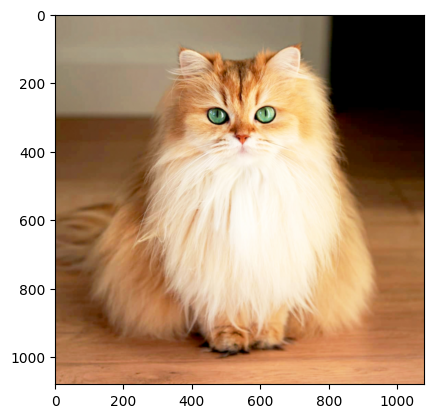

In [17]:
# AverageBlur va GaussianBlur
avg_blur = A.Blur(blur_limit=(11, 31), p=1.0)
gauss_blur = A.GaussianBlur(blur_limit=(5, 15), p=1.0)

img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(avg_blur(image=img_rgb)['image'])
plt.show()
plt.imshow(gauss_blur(image=img_rgb)['image'])
plt.show()


- Dropout: Biến đổi ngẫu nhiên một phần ảnh thành các pixel đen 

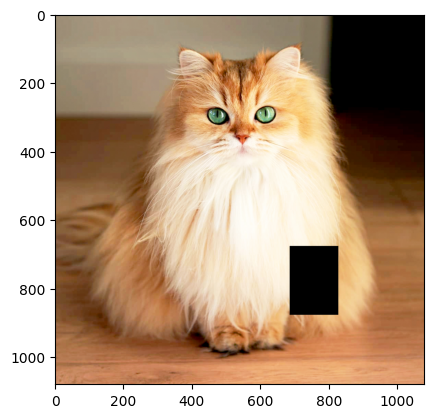

In [18]:
# CoarseDropout: xoa ngau nhien mot phan anh
dropout = A.CoarseDropout(max_holes=50, max_height=8, max_width=8, p=1.0)

img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = dropout(image=img_rgb)['image']
plt.imshow(result)
plt.show()


### Kết hợp nhiều augmenter

Trong thực tế, có nhiều chiến lược trong việc thực hiện các augmenter khác nhau, thư viện imgaug cũng hỗ trợ một số hàm để thực hiện công việc này:

- Sequential: Áp dụng các augmenter lần lượt theo thứ tự truyền vào:

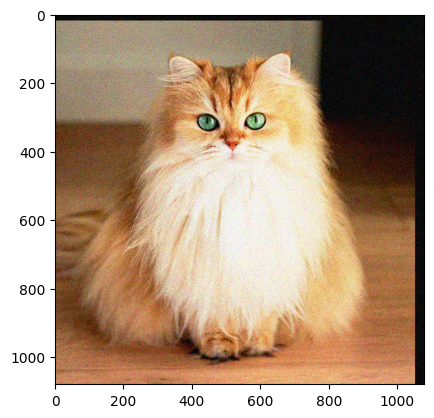

In [19]:
# Compose: ap dung nhieu augmenter lien tiep
aug = A.Compose([
    A.ShiftScaleRotate(shift_limit=40/image.shape[1], scale_limit=0, rotate_limit=0, p=1.0),
    A.GaussNoise(std_range=(0.05, 0.15), p=1.0)
])

img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = aug(image=img_rgb)['image']
plt.imshow(result)
plt.show()


- SomeOf: Áp dụng ngẫu nhiên một vài augmenter trong list các augmenter:

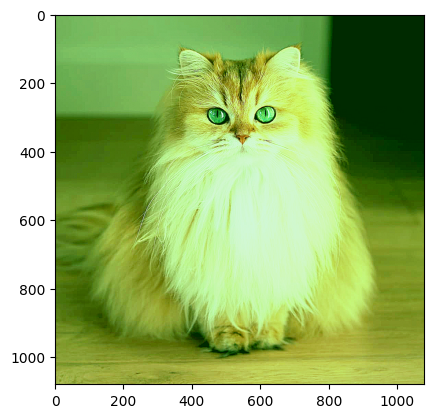

In [20]:
# SomeOf: ap dung ngau nhien mot so augmenter
aug = A.SomeOf([
    A.Affine(rotate=45, p=1.0),
    A.GaussNoise(std_range=(0.1, 0.3), p=1.0),
    A.RGBShift(r_shift_limit=50, g_shift_limit=50, b_shift_limit=50, p=1.0),
    A.Sharpen(alpha=(0.5, 0.5), p=1.0)
], n=2, p=1.0)

img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = aug(image=img_rgb)['image']
plt.imshow(result)
plt.show()


- Sometimes: Áp dụng augmenter với xác suất p:

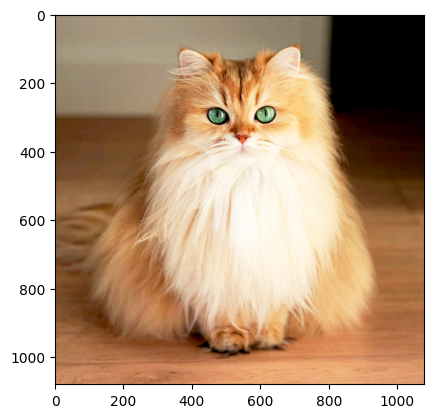

In [21]:
# OneOf voi xac suat: tuong duong Sometimes
aug = A.OneOf([
    A.GaussianBlur(blur_limit=(19, 21), p=1.0)
], p=0.5)

img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = aug(image=img_rgb)['image']
plt.imshow(result)
plt.show()


### Kết hợp cùng thư viện Keras

Bây giờ chúng ta sẽ sử dụng các augmenter đã viết để thực hiện augment image trong quá trình huấn luyện mạng với thư viện Keras. 

- Bước 1: Khởi tạo Augmenter:

In [22]:
# Augmenter nhe cho training
our_aug = A.CoarseDropout(max_holes=5, max_height=2, max_width=2, p=0.5)


- Bước 2: Xây dựng generator:

In [23]:
class Generator(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [24]:
training_data = Generator(x_train, y_train)
train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True)

In [25]:
test_data = Generator(x_test, y_test)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True)

Quan sát thử kết quả của generator bên trên:

torch.Size([32, 28, 28])


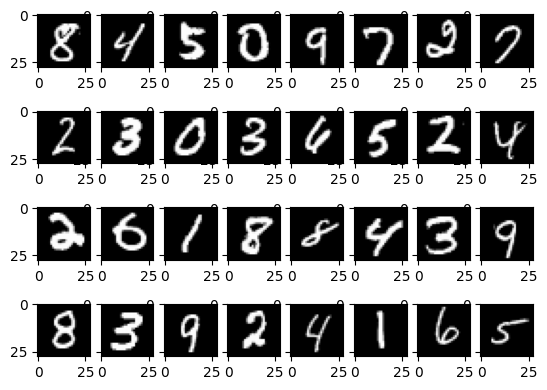

In [26]:
for (batch_idx, target_tuple) in enumerate(train_dataloader):
    print(target_tuple[0].shape)
    for i in range(32):
        plt.subplot(4, 8, i + 1), plt.imshow(target_tuple[0][i], cmap='gray')
    plt.show()
    break

- Bước 3: Train model với fit_generator:

In [27]:
use_cuda = torch.cuda.is_available()
best_loss = float('inf')

model = SimpleModel(dropout_rate=0.5)

optimizer = torch.optim.Adadelta(model.parameters())

if use_cuda:
    model = model.cuda()
    torch.backends.cudnn.benchmark = True


In [28]:
def train(epoch):
    print('Train phase, Epoch:', epoch)
    model.train()
    train_loss = 0
    print('Learning rate:', optimizer.param_groups[0]['lr'])

    for batch_idx, target_tuple in enumerate(train_dataloader):
        if use_cuda:
            target_tuple = [t.cuda(non_blocking=True) for t in target_tuple]
        images, labels = target_tuple
        labels = torch.tensor(labels, dtype=torch.long)
        optimizer.zero_grad()
        output = model(images)
        loss = F.nll_loss(output, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        print('Epoch:', epoch, 'batch:', batch_idx, '/', len(train_dataloader),
              'loss: %.3f avg: %.3f' % (loss.item(), train_loss / (batch_idx + 1)))

    global best_loss
    train_loss /= len(train_dataloader)
    noti = 'best_' if train_loss < best_loss else ''
    if train_loss < best_loss:
        best_loss = train_loss
    state = {
        'weights': model.state_dict(),
        'optimizer_weight': optimizer.state_dict(),
        'train_loss': train_loss,
        'epoch': epoch,
    }
    os.makedirs('checkpoints', exist_ok=True)
    torch.save(state, 'checkpoints/model_' + noti + str(epoch) + '_epoch.pth')


In [29]:
def test(epoch):
    print('Test phase, Epoch:', epoch)
    model.eval()
    with torch.no_grad():
        test_loss = 0
        for batch_idx, target_tuple in enumerate(test_dataloader):
            if use_cuda:
                target_tuple = [t.cuda(non_blocking=True) for t in target_tuple]
            images, labels = target_tuple
            labels = torch.tensor(labels, dtype=torch.long)
            output = model(images)
            loss = F.nll_loss(output, labels)
            test_loss += loss.item()
            print('Epoch:', epoch, 'batch:', batch_idx, '/', len(test_dataloader),
                  'loss: %.3f avg: %.3f' % (loss.item(), test_loss / (batch_idx + 1)))


In [30]:
no_epoch = 5
for epoch in range(no_epoch):
    train(epoch)
    test(epoch)

Train phase, Epoch: 0
Learning rate: 1.0
Epoch: 0 batch: 0 / 1875 loss: 2.312 avg: 2.312
Epoch: 0 batch: 1 / 1875 loss: 2.232 avg: 2.272
Epoch: 0 batch: 2 / 1875 loss: 2.189 avg: 2.244
Epoch: 0 batch: 3 / 1875 loss: 2.085 avg: 2.204
Epoch: 0 batch: 4 / 1875 loss: 2.160 avg: 2.195
Epoch: 0 batch: 5 / 1875 loss: 2.088 avg: 2.177
Epoch: 0 batch: 6 / 1875 loss: 2.016 avg: 2.154
Epoch: 0 batch: 7 / 1875 loss: 1.835 avg: 2.114
Epoch: 0 batch: 8 / 1875 loss: 2.026 avg: 2.105
Epoch: 0 batch: 9 / 1875 loss: 1.793 avg: 2.074
Epoch: 0 batch: 10 / 1875 loss: 1.844 avg: 2.053
Epoch: 0 batch: 11 / 1875 loss: 1.789 avg: 2.031
Epoch: 0 batch: 12 / 1875 loss: 1.629 avg: 2.000
Epoch: 0 batch: 13 / 1875 loss: 1.842 avg: 1.989
Epoch: 0 batch: 14 / 1875 loss: 1.451 avg: 1.953
Epoch: 0 batch: 15 / 1875 loss: 1.396 avg: 1.918
Epoch: 0 batch: 16 / 1875 loss: 1.521 avg: 1.895
Epoch: 0 batch: 17 / 1875 loss: 1.243 avg: 1.858
Epoch: 0 batch: 18 / 1875 loss: 1.249 avg: 1.826
Epoch: 0 batch: 19 / 1875 loss: 1.298 